# 01 - Análisis Exploratorio de Datos (EDA)

**Autor:** Julian Barbieri  
**Objetivo:** Exploración profunda de la estructura y características de los datos

---

## Cargar y explorar datos

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Cargar datos
df = pd.read_csv('../data/raw/ventasTransformed.csv', encoding='latin-1')
print(f"Dimensiones: {df.shape}")
print(f"\nPrimeras filas:")
display(df.head())

Dimensiones: (30000, 33)

Primeras filas:


,VentaID,Anio,Trimestre,Mes,Dia,HoraVenta,SucursalNombre,CiudadSucursal,VendedorNombre,ClienteNombre,...,CantidadProducto2,PrecioUnitarioProducto2,SubtotalProducto2,NombreProducto3,MarcaProducto3,CantidadProducto3,PrecioUnitarioProducto3,SubtotalProducto3,DescuentoVenta,TotalVenta
0,1,2015,Qtr 4,diciembre,31,1899-12-30 05:42:43,Techcore Pereira,Pereira,Amílcar Ortega-Alberto,Bienvenida Nebot-Fiol,...,2,"$8,000,000.00","$16,000,000.00",Dell Latitude 7420,Dell,1,"$5,600,000.00","$5,600,000.00",0.00%,"$31,200,000.00"
1,2,2019,Qtr 1,marzo,23,1899-12-30 19:03:21,Techcore Medellín #1,Medellín,Ana Sofía Llopis Blázquez,Teófila Bueno-Novoa,...,1,"$6,800,000.00","$6,800,000.00",NaN,NaN,0,NaN,NaN,0.00%,"$10,800,000.00"
2,3,2018,Qtr 4,diciembre,23,1899-12-30 02:32:34,Techcore Medellín #2,Medellín,Juan José Porcel-Riera,Gilberto Chamorro Catalá,...,1,"$7,200,000.00","$7,200,000.00",HP Pavilion 15,HP,1,"$3,500,000.00","$3,500,000.00",0.00%,"$21,900,000.00"
3,4,2015,Qtr 4,noviembre,14,1899-12-30 00:37:36,Techcore Medellín #2,Medellín,Juan José Porcel-Riera,Máximo Coronado Huerta,...,2,"$4,400,000.00","$8,800,000.00",NaN,NaN,0,NaN,NaN,0.00%,"$13,600,000.00"
4,5,2016,Qtr 4,noviembre,29,1899-12-30 10:34:20,Techcore Cali,Cali,Jacinta Juárez Marín,Yago Oliver,...,1,"$3,500,000.00","$3,500,000.00",Microsoft Surface Laptop 4,Microsoft,1,"$5,200,000.00","$5,200,000.00",0.00%,"$13,900,000.00"


## Información general

In [3]:
print(f"Total de columnas: {df.shape[1]}")
print(f"\nNombres de columnas:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2d}. {col}")

Total de columnas: 33

Nombres de columnas:
   1. VentaID
   2. Anio
   3. Trimestre
   4. Mes
   5. Dia
   6. HoraVenta
   7. SucursalNombre
   8. CiudadSucursal
   9. VendedorNombre
  10. ClienteNombre
  11. GeneroCliente
  12. EdadCliente
  13. EmailCliente
  14. TelefonoCliente
  15. DireccionCliente
  16. MetodoPago
  17. NombreProducto1
  18. MarcaProducto1
  19. CantidadProducto1
  20. PrecioUnitarioProducto1
  21. SubtotalProducto1
  22. NombreProducto2
  23. MarcaProducto2
  24. CantidadProducto2
  25. PrecioUnitarioProducto2
  26. SubtotalProducto2
  27. NombreProducto3
  28. MarcaProducto3
  29. CantidadProducto3
  30. PrecioUnitarioProducto3
  31. SubtotalProducto3
  32. DescuentoVenta
  33. TotalVenta


## Valores faltantes

In [4]:
faltantes = df.isnull().sum()
faltantes = faltantes[faltantes > 0].sort_values(ascending=False)

if len(faltantes) > 0:
    print("Valores faltantes por columna:")
    for col, count in faltantes.items():
        pct = (count / len(df)) * 100
        print(f"  • {col}: {count:,} ({pct:.2f}%)")
else:
    print("No hay valores faltantes")

Valores faltantes por columna:
  • PrecioUnitarioProducto3: 19,953 (66.51%)
  • SubtotalProducto3: 19,953 (66.51%)
  • MarcaProducto3: 19,953 (66.51%)
  • NombreProducto3: 19,953 (66.51%)
  • SubtotalProducto2: 9,988 (33.29%)
  • PrecioUnitarioProducto2: 9,988 (33.29%)
  • MarcaProducto2: 9,988 (33.29%)
  • NombreProducto2: 9,988 (33.29%)
  • EmailCliente: 1,563 (5.21%)
  • TelefonoCliente: 295 (0.98%)


## Análisis por dimensión

### Ciudades

In [5]:
print(f"Número de ciudades: {df['CiudadSucursal'].nunique()}")
print(f"\nDistribución:")
print(df['CiudadSucursal'].value_counts())

Número de ciudades: 4

Distribución:
CiudadSucursal
Medellín    13460
Bogotá       9107
Pereira      3723
Cali         3710
Name: count, dtype: int64


### Clientes

In [6]:
print(f"Número de clientes únicos: {df['ClienteNombre'].nunique():,}")
print(f"\nDistribución por género:")
print(df['GeneroCliente'].value_counts())
print(f"\nEstadísticas de edad:")
print(df['EdadCliente'].describe())

Número de clientes únicos: 17,449

Distribución por género:
GeneroCliente
M    19563
F    10437
Name: count, dtype: int64

Estadísticas de edad:
count    30000.000000
mean        34.460100
std          9.856249
min         18.000000
25%         26.000000
50%         34.000000
75%         43.000000
max         51.000000
Name: EdadCliente, dtype: float64


### Productos

In [7]:
# Consolidar productos
productos = []
for col in ['NombreProducto1', 'NombreProducto2', 'NombreProducto3']:
    productos.extend(df[col].dropna().unique())
productos = list(set(productos))

print(f"Número de productos únicos: {len(productos)}")
print(f"\nMarcas disponibles: {df['MarcaProducto1'].nunique() + df['MarcaProducto2'].nunique() + df['MarcaProducto3'].nunique()}")

Número de productos únicos: 40

Marcas disponibles: 30


### Vendedores

In [8]:
print(f"Número de vendedores: {df['VendedorNombre'].nunique()}")
print(f"\nVentas por vendedor (top 10):")
display(df['VendedorNombre'].value_counts().head(10))

Número de vendedores: 30

Ventas por vendedor (top 10):


VendedorNombre
Ana Sofía Llopis Blázquez          1536
Liliana Jordá Armengol             1517
Dominga del Alcántara              1477
Ibán López Córdoba                 1468
Eusebia Jara Macias                1460
Juan José Porcel-Riera             1243
Claudia Sastre-Quintero            1231
Juanito Diaz                       1189
Luisina Lasa                       1174
Almudena Adelaida Lledó Garrido    1165
Name: count, dtype: int64

### Temporal

In [9]:
print(f"Años cubiertos: {sorted(df['Anio'].unique())}")
print(f"\nTotal de registros por año:")
print(df.groupby('Anio').size())

Años cubiertos: [np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]

Total de registros por año:
Anio
2014     832
2015    2640
2016    2638
2017    2824
2018    2755
2019    2757
2020    2686
2021    2740
2022    2765
2023    2778
2024    2756
2025    1829
dtype: int64


### Métodos de Pago

In [10]:
print(f"Métodos de pago disponibles:")
print(df['MetodoPago'].value_counts())

Métodos de pago disponibles:
MetodoPago
Tarjeta Crédito      12044
Tarjeta Débito        6106
Transferencia         4515
Billetera Digital     2946
Efectivo              2942
No especificado       1447
Name: count, dtype: int64


## Análisis de montos

In [11]:
# Limpiar TotalVenta
df['TotalVenta_clean'] = df['TotalVenta'].astype(str).str.replace('$', '').str.replace(',', '').astype(float)

print(f"Estadísticas de TotalVenta:")
print(df['TotalVenta_clean'].describe())

Estadísticas de TotalVenta:
count    3.000000e+04
mean     1.521639e+07
std      8.235931e+06
min      1.700000e+06
25%      8.640000e+06
50%      1.440000e+07
75%      2.080000e+07
max      4.880000e+07
Name: TotalVenta_clean, dtype: float64


## Visualizaciones

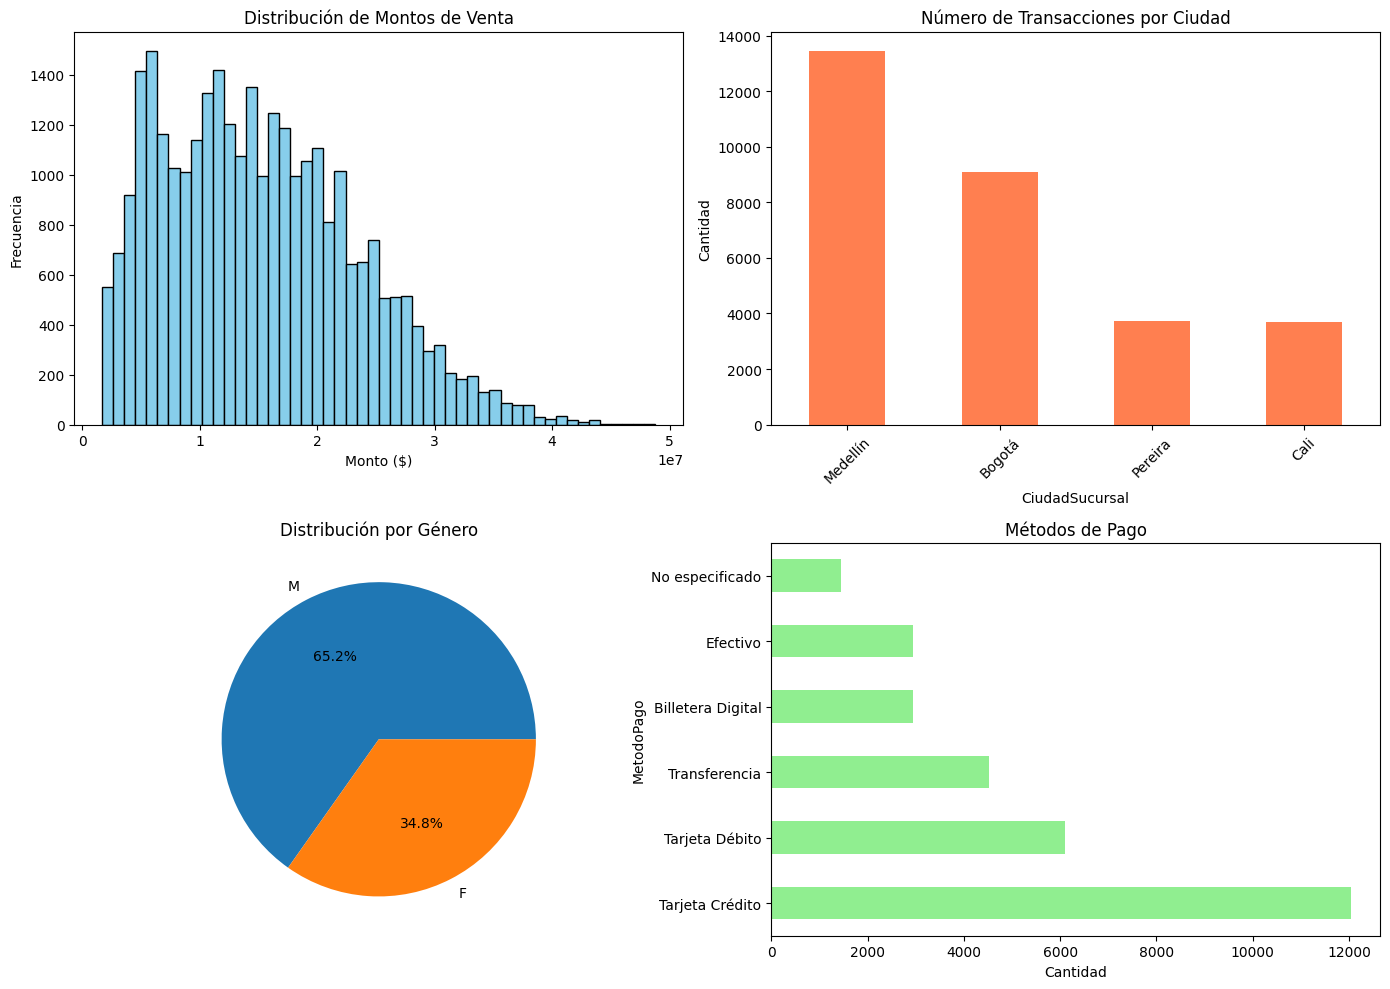

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Distribución de montos
axes[0, 0].hist(df['TotalVenta_clean'], bins=50, edgecolor='black', color='skyblue')
axes[0, 0].set_title('Distribución de Montos de Venta')
axes[0, 0].set_xlabel('Monto ($)')
axes[0, 0].set_ylabel('Frecuencia')

# Ventas por ciudad
df['CiudadSucursal'].value_counts().plot(kind='bar', ax=axes[0, 1], color='coral')
axes[0, 1].set_title('Número de Transacciones por Ciudad')
axes[0, 1].set_ylabel('Cantidad')
axes[0, 1].tick_params(axis='x', rotation=45)

# Género
df['GeneroCliente'].value_counts().plot(kind='pie', ax=axes[1, 0], autopct='%1.1f%%')
axes[1, 0].set_title('Distribución por Género')
axes[1, 0].set_ylabel('')

# Métodos de pago
df['MetodoPago'].value_counts().plot(kind='barh', ax=axes[1, 1], color='lightgreen')
axes[1, 1].set_title('Métodos de Pago')
axes[1, 1].set_xlabel('Cantidad')

plt.tight_layout()
plt.show()